# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

## Task 1

**Task 1.1**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import matplotlib.pyplot as plt

In [3]:
DATA_PATH = "/content/drive/MyDrive/DL4AI-220080-project/data_nasdaq_csv/csv/AAPL.csv"
df = pd.read_csv(DATA_PATH)

df = df.sort_values('Date')

feature_columns = [
    'Low',
    'Open',
    'Volume',
    'High',
    'Close',
    'Adjusted Close'
]

data = df[feature_columns]

print(data.head())

           Low      Open     Volume      High     Close  Adjusted Close
286   0.089844  0.090960   38528000  0.090960  0.089844        0.069912
540   0.179688  0.182478  210963200  0.186384  0.186384        0.145034
793   0.109375  0.110491  163116800  0.113839  0.109933        0.085544
1047  0.126674  0.129464  137737600  0.130022  0.127790        0.099440
1803  0.369420  0.372768  199360000  0.379464  0.372768        0.291520


In [4]:
# Validation check for date sorting
# Ensure 'Date' is datetime objects to sort chronologically, not alphabetically
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)
print("Date range verified:", df['Date'].min(), "to", df['Date'].max())

Date range verified: 1980-12-12 00:00:00 to 2022-12-12 00:00:00


In [5]:
# Fix data leakage: fit scaler ONLY on training portion
train_size_raw = int(len(data) * 0.8)

scaler = MinMaxScaler()
scaler.fit(data.iloc[:train_size_raw])

# Transform full dataset with train-fitted scaler
scaled_data = scaler.transform(data)
print('scaled_data shape:', scaled_data.shape)


scaled_data shape: (10590, 6)


In [6]:
TIME_STEPS = 30

X = []
y = []

for i in range(TIME_STEPS, len(scaled_data)):

    X.append(scaled_data[i-TIME_STEPS:i])

    # predict Close price
    close_index = feature_columns.index('Close')

    y.append(scaled_data[i, close_index])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(10560, 30, 6)
(10560,)


In [7]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(8448, 30, 6)
(2112, 30, 6)


In [8]:
model = Sequential()

model.add(LSTM(64, return_sequences=True,
               input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,265 (200.25 KB)

 Trainable params: 51,265 (200.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0221 - val_loss: 0.0172
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0146 - val_loss: 0.0115
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0112 - val_loss: 0.0101
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0110 - val_loss: 0.0093
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0105 - val_loss: 0.0101
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0094 - val_loss: 0.0084
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0097 - val_loss: 0.0086
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0088 - val_loss: 0.0081
Epoch 9/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0091 - val_loss: 0.0072
Epoch 10/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0088 - val_loss: 0.0089
Epoch 11/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0088 - val_loss: 0.0084
Epoch 12/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/

In [10]:
predictions = model.predict(X_test)

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [11]:
close_index = feature_columns.index('Close')

dummy = np.zeros((len(predictions), len(feature_columns)))

dummy[:, close_index] = predictions[:, 0]

predicted_prices = scaler.inverse_transform(dummy)[:, close_index]

In [12]:
dummy_real = np.zeros((len(y_test), len(feature_columns)))

dummy_real[:, close_index] = y_test

real_prices = scaler.inverse_transform(dummy_real)[:, close_index]

In [13]:
mae = mean_absolute_error(real_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(real_prices, predicted_prices))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 5.807211040957114
RMSE: 15.820068013403187


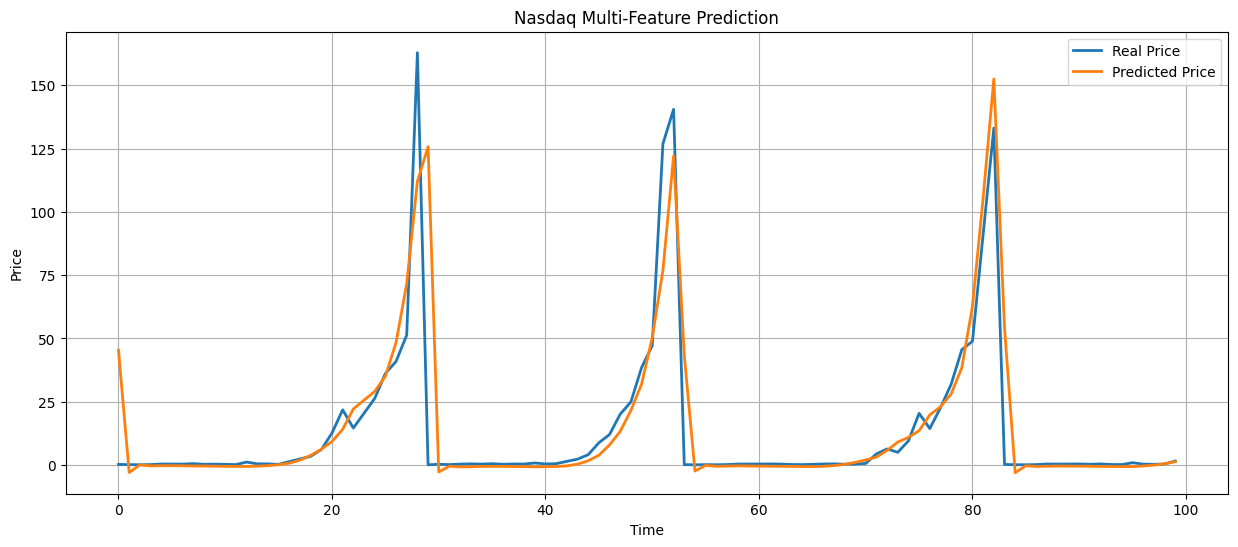

In [14]:
plt.figure(figsize=(15,6))

plt.plot(
    real_prices[:100],
    label='Real Price',
    linewidth=2
)

plt.plot(
    predicted_prices[:100],
    label='Predicted Price',
    linewidth=2
)

plt.title('Nasdaq Multi-Feature Prediction')

plt.xlabel('Time')

plt.ylabel('Price')

plt.legend()

plt.grid(True)

plt.show()

The original demo code used only the Open price as input.

This task extends the model to use multiple stock features:
- Low
- Open
- Volume
- High
- Close
- Adjusted Close

The LSTM model therefore learns richer market behavior and temporal patterns.

**Task 1.2**

In [15]:
# =========================
# TASK 1.2 - KTH DAY FORECAST
# =========================

TIME_STEPS = 30

K_DAY = 7
# Example:
# K_DAY = 3 -> predict 3rd future day
# K_DAY = 7 -> predict 7th future day

X = []
y = []

close_index = feature_columns.index('Close')

for i in range(TIME_STEPS, len(scaled_data) - K_DAY):

    # Past 30 days input
    X.append(
        scaled_data[i-TIME_STEPS:i]
    )

    # Predict K-th future Close price
    y.append(
        scaled_data[i + K_DAY, close_index]
    )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10553, 30, 6)
y shape: (10553,)


In [16]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(8442, 30, 6)
(2111, 30, 6)


In [17]:
model = Sequential()

model.add(LSTM(64, return_sequences=True,
               input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,265 (200.25 KB)

 Trainable params: 51,265 (200.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0261 - val_loss: 0.0242
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0202 - val_loss: 0.0184
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0170 - val_loss: 0.0159
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0154 - val_loss: 0.0164
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0144 - val_loss: 0.0133
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0136 - val_loss: 0.0174
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0133 - val_loss: 0.0199
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0134 - val_loss: 0.0150
Epoch 9/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0127 - val_loss: 0.0130
Epoch 10/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0122 - val_loss: 0.0142
Epoch 11/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0122 - val_loss: 0.0136
Epoch 12/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/

In [19]:
predictions = model.predict(X_test)

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [20]:
close_index = feature_columns.index('Close')

dummy = np.zeros((len(predictions), len(feature_columns)))

dummy[:, close_index] = predictions[:, 0]

predicted_prices = scaler.inverse_transform(dummy)[:, close_index]

In [21]:
dummy_real = np.zeros((len(y_test), len(feature_columns)))

dummy_real[:, close_index] = y_test

real_prices = scaler.inverse_transform(dummy_real)[:, close_index]

In [22]:
mae = mean_absolute_error(real_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(real_prices, predicted_prices))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 8.815427129261433
RMSE: 21.529100531632412


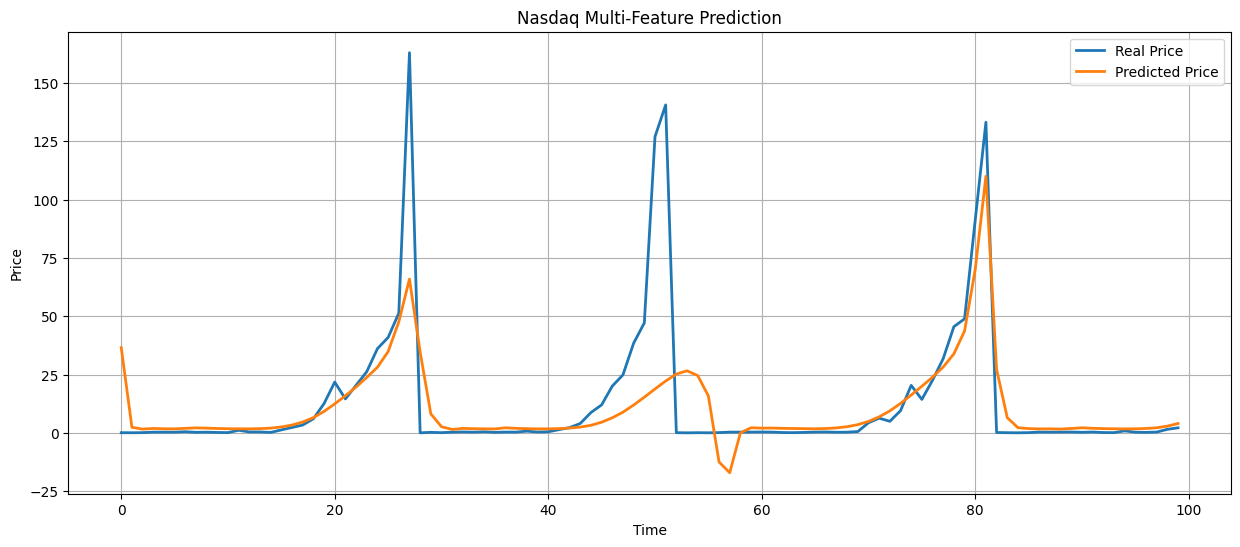

In [23]:
plt.figure(figsize=(15,6))

plt.plot(
    real_prices[:100],
    label='Real Price',
    linewidth=2
)

plt.plot(
    predicted_prices[:100],
    label='Predicted Price',
    linewidth=2
)

plt.title('Nasdaq Multi-Feature Prediction')

plt.xlabel('Time')

plt.ylabel('Price')

plt.legend()

plt.grid(True)

plt.show()

Instead of predicting the next-day stock price, the model predicts the stock price on the k-th future day (e.g., 7th day ahead).

**Task 1.3**

In [24]:
# ======================================
# TASK 1.3 — K DAYS FORECAST
# ======================================

TIME_STEPS = 30

K_DAYS = 7
# Example:
# 3 -> predict next 3 days
# 7 -> predict next 7 days

X = []
y = []

close_index = feature_columns.index('Close')

for i in range(TIME_STEPS, len(scaled_data) - K_DAYS):

    # Input: previous 30 days
    X.append(
        scaled_data[i-TIME_STEPS:i]
    )

    # Output: next K consecutive days
    y.append(
        scaled_data[i:i + K_DAYS, close_index]
    )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10553, 30, 6)
y shape: (10553, 7)


In [25]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(8442, 30, 6)
(2111, 30, 6)


In [26]:
model = Sequential()

model.add(LSTM(64, return_sequences=True,
               input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dropout(0.2))

model.add(Dense(K_DAYS))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,655 (201.78 KB)

 Trainable params: 51,655 (201.78 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0237 - val_loss: 0.0187
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0170 - val_loss: 0.0156
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0143 - val_loss: 0.0140
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0130 - val_loss: 0.0139
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0122 - val_loss: 0.0117
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0116
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0112 - val_loss: 0.0110
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0109 - val_loss: 0.0105
Epoch 9/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0104 - val_loss: 0.0111
Epoch 10/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0103 - val_loss: 0.0107
Epoch 11/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0101 - val_loss: 0.0100
Epoch 12/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/

In [28]:
predictions = model.predict(X_test)

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [29]:
# ======================================
# INVERSE TRANSFORM FOR MULTI-DAY OUTPUT
# ======================================

predicted_prices = []
real_prices = []

for day in range(K_DAYS):

    # Predicted
    dummy_pred = np.zeros((len(predictions), len(feature_columns)))

    dummy_pred[:, close_index] = predictions[:, day]

    inv_pred = scaler.inverse_transform(dummy_pred)[:, close_index]

    predicted_prices.append(inv_pred)


    # Real
    dummy_real = np.zeros((len(y_test), len(feature_columns)))

    dummy_real[:, close_index] = y_test[:, day]

    inv_real = scaler.inverse_transform(dummy_real)[:, close_index]

    real_prices.append(inv_real)

predicted_prices = np.array(predicted_prices)
real_prices = np.array(real_prices)

print(predicted_prices.shape)
print(real_prices.shape)

(7, 2111)
(7, 2111)


In [30]:
# ======================================
# EVALUATE EACH FUTURE DAY
# ======================================

for day in range(K_DAYS):

    mae = mean_absolute_error(
        real_prices[day],
        predicted_prices[day]
    )

    rmse = np.sqrt(
        mean_squared_error(
            real_prices[day],
            predicted_prices[day]
        )
    )

    print(f"\nDay {day+1} Forecast")

    print("MAE :", mae)
    print("RMSE:", rmse)


Day 1 Forecast
MAE : 6.665116275740847
RMSE: 17.031795002521076

Day 2 Forecast
MAE : 6.719822224324755
RMSE: 17.62048640701207

Day 3 Forecast
MAE : 6.773163928053512
RMSE: 18.047370142930763

Day 4 Forecast
MAE : 7.278730339001939
RMSE: 18.387835068163028

Day 5 Forecast
MAE : 7.60901267830476
RMSE: 19.49037573436862

Day 6 Forecast
MAE : 7.957160118156899
RMSE: 19.238667281467254

Day 7 Forecast
MAE : 8.406692743600157
RMSE: 20.144579825453878


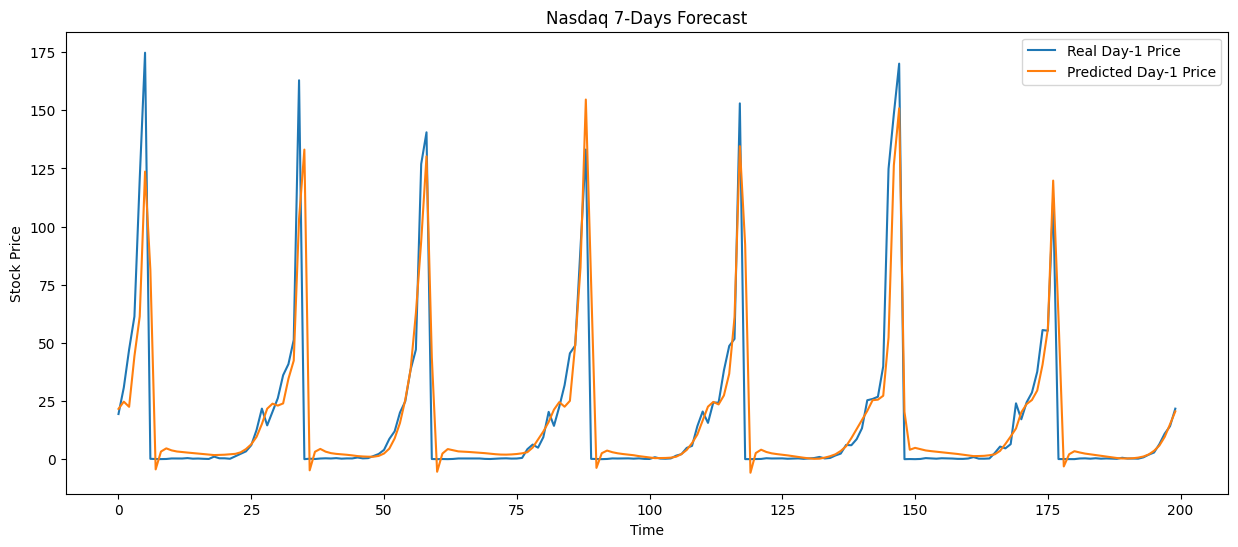

In [31]:
# ======================================
# VISUALIZE DAY-1 PREDICTION
# ======================================

plt.figure(figsize=(15,6))

plt.plot(
    real_prices[0][:200],
    label='Real Day-1 Price'
)

plt.plot(
    predicted_prices[0][:200],
    label='Predicted Day-1 Price'
)

plt.title(f'Nasdaq {K_DAYS}-Days Forecast')

plt.xlabel('Time')

plt.ylabel('Stock Price')

plt.legend()

plt.show()

The model is extended to predict multiple future days simultaneously using a multi-output LSTM architecture.

# TASK 2

# Task 2.1 — Vietnam Multi-Feature Extension

In [32]:
DATA_PATH = "/content/drive/MyDrive/DL4AI-220080-project/data-vn-20230228/stock-historical-data/VNM-VNINDEX-History.csv"
df = pd.read_csv(DATA_PATH)

df = df.sort_values('TradingDate')

feature_columns = [
    'Low',
    'Open',
    'Volume',
    'High',
    'Close',
]

data = df[feature_columns]

print(data.head())

      Low    Open  Volume    High   Close
0  2565.0  2565.0  109350  2565.0  2565.0
1  2614.0  2662.0  157840  2662.0  2614.0
2  2541.0  2614.0   81400  2614.0  2541.0
3  2517.0  2541.0   66000  2541.0  2517.0
4  2517.0  2517.0   57220  2565.0  2565.0


In [33]:
df['TradingDate'] = pd.to_datetime(df['TradingDate'], format='%Y-%m-%d')
df = df.sort_values('TradingDate').reset_index(drop=True)
print("Date range verified:", df['TradingDate'].min(), "to", df['TradingDate'].max())

Date range verified: 2006-01-19 00:00:00 to 2023-02-28 00:00:00


In [34]:
# Fix data leakage: fit scaler ONLY on training portion
train_size_raw = int(len(data) * 0.8)

scaler = MinMaxScaler()
scaler.fit(data.iloc[:train_size_raw])

# Transform full dataset with train-fitted scaler
scaled_data = scaler.transform(data)
print('scaled_data shape:', scaled_data.shape)


scaled_data shape: (4264, 5)


In [35]:
TIME_STEPS = 30


X = []
y = []


for i in range(TIME_STEPS, len(scaled_data)):


   X.append(scaled_data[i-TIME_STEPS:i])


   # predict Close price
   close_index = feature_columns.index('Close')


   y.append(scaled_data[i, close_index])


X = np.array(X)
y = np.array(y)


print(X.shape)

(4234, 30, 5)


In [36]:
train_size = int(len(X) * 0.8)


X_train = X[:train_size]
X_test = X[train_size:]


y_train = y[:train_size]
y_test = y[train_size:]


print(X_train.shape)
print(X_test.shape)

(3387, 30, 5)
(847, 30, 5)


In [37]:
model = Sequential()


model.add(LSTM(64, return_sequences=True,
              input_shape=(X_train.shape[1], X_train.shape[2])))


model.add(Dropout(0.2))


model.add(LSTM(64))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
model.add(Dropout(0.2))


model.add(Dense(1))


model.compile(
   optimizer='adam',
   loss='mse'
)


model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,009 (199.25 KB)

 Trainable params: 51,009 (199.25 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = model.fit(
   X_train,
   y_train,
   epochs=20,
   batch_size=32,
   validation_split=0.1,
   verbose=1
)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0042 - val_loss: 7.3592e-04
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 6.6450e-04
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010 - val_loss: 0.0037
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.7238e-04 - val_loss: 0.0020
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.0337e-04 - val_loss: 0.0026
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.1771e-04 - val_loss: 0.0019
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.7875e-04 - val_loss: 0.0025
Epoch 9/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.5140e-04 - val_loss: 6.7191e-04
Epoch 10/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.5639e-04 - val_loss: 5.5502e-04
Epoch 11/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.7404e-04 - val_loss: 0.0011
Epoch 12/20
96/96 ━━━━━━━━━━━

In [40]:
predictions = model.predict(X_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [41]:
close_index = feature_columns.index('Close')


dummy = np.zeros((len(predictions), len(feature_columns)))


dummy[:, close_index] = predictions[:, 0]


predicted_prices = scaler.inverse_transform(dummy)[:, close_index]


dummy_real = np.zeros((len(y_test), len(feature_columns)))


dummy_real[:, close_index] = y_test


real_prices = scaler.inverse_transform(dummy_real)[:, close_index]

In [42]:
mae = mean_absolute_error(real_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(real_prices, predicted_prices))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2293.9874039689935
RMSE: 2886.849088153827


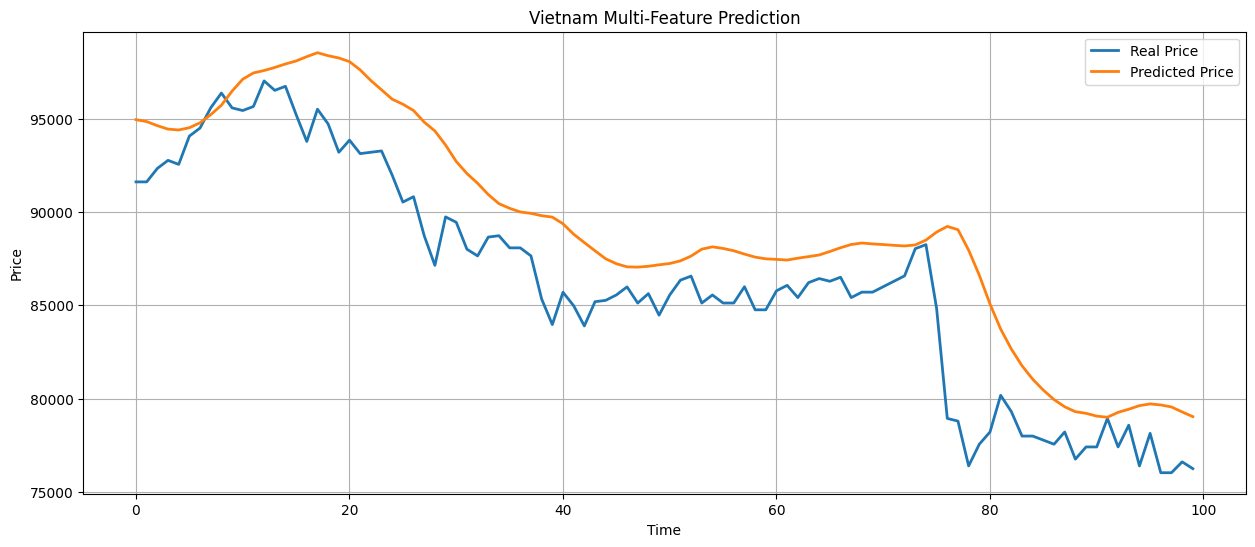

In [43]:
plt.figure(figsize=(15,6))

plt.plot(
   real_prices[:100],
   label='Real Price',
   linewidth=2
)

plt.plot(
   predicted_prices[:100],
   label='Predicted Price',
   linewidth=2
)

plt.title('Vietnam Multi-Feature Prediction')

plt.xlabel('Time')

plt.ylabel('Price')

plt.legend()

plt.grid(True)

plt.show()

## TASK 2.2

In [44]:
# =========================
# TASK 2.2 - KTH DAY FORECAST (Vietnam Dataset)
# =========================

TIME_STEPS = 30
K_DAY = 7

X = []
y = []

# Using the feature columns and scaled_data already prepared for Vietnam in Task 2.1
close_index = feature_columns.index('Close')

for i in range(TIME_STEPS, len(scaled_data) - K_DAY):
    # Past 30 days input
    X.append(scaled_data[i-TIME_STEPS:i])
    # Predict K-th future Close price
    y.append(scaled_data[i + K_DAY, close_index])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4227, 30, 5)
y shape: (4227,)


In [45]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (3381, 30, 5)
Testing set: (846, 30, 5)


In [46]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0055 - val_loss: 0.0024
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015 - val_loss: 0.0037
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0021
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 0.0023
Epoch 9/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 10/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 11/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0026
Epoch 12/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.4206e-04 - val_loss: 

In [47]:
predictions = model.predict(X_test)

# Inverse transform to get actual prices
dummy = np.zeros((len(predictions), len(feature_columns)))
dummy[:, close_index] = predictions[:, 0]
predicted_prices = scaler.inverse_transform(dummy)[:, close_index]

dummy_real = np.zeros((len(y_test), len(feature_columns)))
dummy_real[:, close_index] = y_test
real_prices = scaler.inverse_transform(dummy_real)[:, close_index]

mae = mean_absolute_error(real_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(real_prices, predicted_prices))

print("MAE:", mae)
print("RMSE:", rmse)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
MAE: 6297.66404747512
RMSE: 7057.450555721904


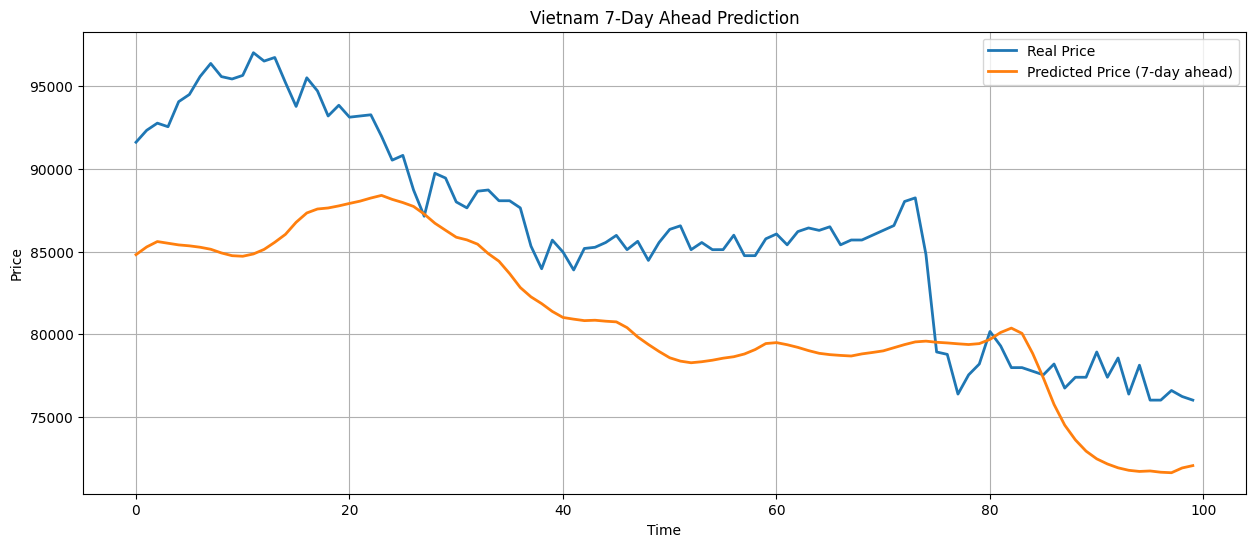

In [48]:
plt.figure(figsize=(15,6))
plt.plot(real_prices[:100], label='Real Price', linewidth=2)
plt.plot(predicted_prices[:100], label='Predicted Price (7-day ahead)', linewidth=2)
plt.title('Vietnam 7-Day Ahead Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

## Task 2.3 — Vietnam K-Days Forecast
This task replicates Task 1.3 using the Vietnam stock dataset to predict the next 7 consecutive days.

In [49]:
# ======================================
# TASK 2.3 — K DAYS FORECAST (Vietnam)
# ======================================

TIME_STEPS = 30
K_DAYS = 7

X = []
y = []

# Using Vietnam scaled_data from Task 2.1
close_index = feature_columns.index('Close')

for i in range(TIME_STEPS, len(scaled_data) - K_DAYS):
    # Input: previous 30 days
    X.append(scaled_data[i-TIME_STEPS:i])
    # Output: next K consecutive days
    y.append(scaled_data[i:i + K_DAYS, close_index])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4227, 30, 5)
y shape: (4227, 7)


In [50]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (3381, 30, 5)
Testing set: (846, 30, 5)


In [51]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(K_DAYS))

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0107 - val_loss: 0.0016
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0029 - val_loss: 0.0032
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0023 - val_loss: 0.0043
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0019 - val_loss: 0.0045
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 0.0048
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0016 - val_loss: 0.0043
Epoch 9/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 10/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 0.0033
Epoch 11/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 9.5887e-04
Epoch 12/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010 - val_loss: 

In [52]:
predictions = model.predict(X_test)

predicted_prices = []
real_prices = []

for day in range(K_DAYS):
    # Predicted inverse
    dummy_pred = np.zeros((len(predictions), len(feature_columns)))
    dummy_pred[:, close_index] = predictions[:, day]
    inv_pred = scaler.inverse_transform(dummy_pred)[:, close_index]
    predicted_prices.append(inv_pred)

    # Real inverse
    dummy_real = np.zeros((len(y_test), len(feature_columns)))
    dummy_real[:, close_index] = y_test[:, day]
    inv_real = scaler.inverse_transform(dummy_real)[:, close_index]
    real_prices.append(inv_real)

predicted_prices = np.array(predicted_prices)
real_prices = np.array(real_prices)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [53]:
for day in range(K_DAYS):
    mae = mean_absolute_error(real_prices[day], predicted_prices[day])
    rmse = np.sqrt(mean_squared_error(real_prices[day], predicted_prices[day]))
    print(f"Day {day+1} Forecast - MAE: {mae:.2f}, RMSE: {rmse:.2f}")

Day 1 Forecast - MAE: 1723.23, RMSE: 2298.83
Day 2 Forecast - MAE: 1918.05, RMSE: 2541.01
Day 3 Forecast - MAE: 2103.30, RMSE: 2786.81
Day 4 Forecast - MAE: 2283.59, RMSE: 2980.16
Day 5 Forecast - MAE: 2500.19, RMSE: 3238.60
Day 6 Forecast - MAE: 2586.11, RMSE: 3332.79
Day 7 Forecast - MAE: 2673.75, RMSE: 3445.84


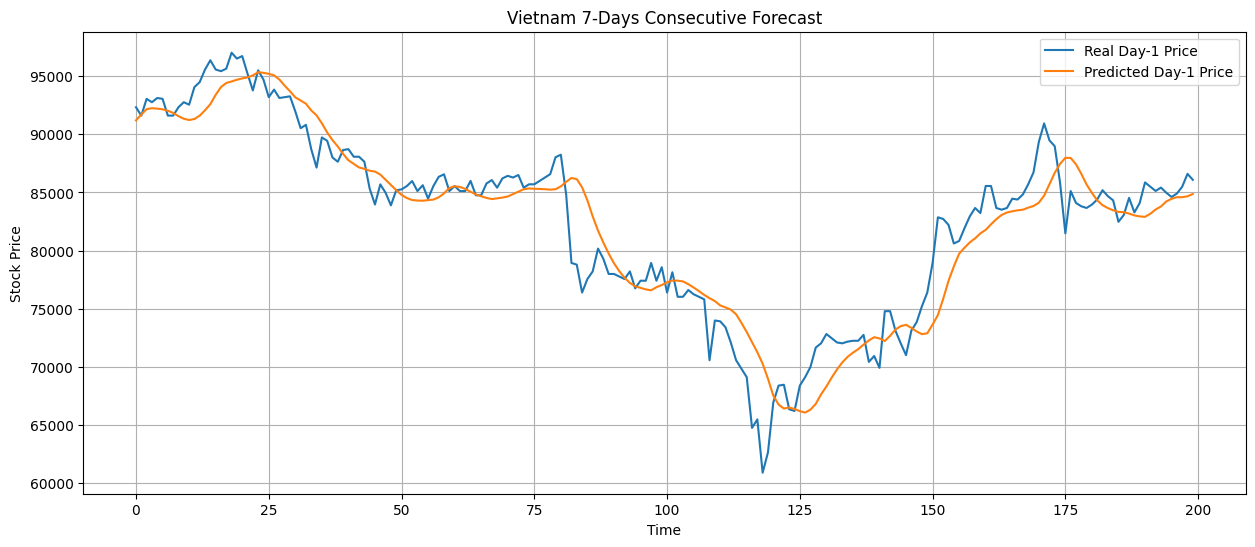

In [54]:
plt.figure(figsize=(15,6))
plt.plot(real_prices[0][:200], label='Real Day-1 Price')
plt.plot(predicted_prices[0][:200], label='Predicted Day-1 Price')
plt.title('Vietnam 7-Days Consecutive Forecast')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

# Task 3.1 — Buying Signal Identification (Vietnam Stock)

In this task, we treat stock trading as a **binary classification** problem.
- **Input:** Past 30 days of multi-feature data.
- **Label (BUY):** 1 if the current price is the minimum within the next 7 days; 0 otherwise.
- **Loss Function:** `binary_crossentropy`.

In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# 1. Load Vietnam Data
DATA_PATH = "/content/drive/MyDrive/DL4AI-220080-project/data-vn-20230228/stock-historical-data/VNM-VNINDEX-History.csv"
df = pd.read_csv(DATA_PATH)
df['TradingDate'] = pd.to_datetime(df['TradingDate'], format='%Y-%m-%d')
df = df.sort_values('TradingDate').reset_index(drop=True)

# 2. Features
feature_columns = ['Low', 'Open', 'Volume', 'High', 'Close']
data = df[feature_columns].values

# 3. Scale Data — fit scaler ONLY on training portion to prevent leakage
train_size_raw = int(len(data) * 0.8)
scaler = MinMaxScaler()
scaler.fit(data[:train_size_raw])
scaled_data = scaler.transform(data)

# 4. Create Buy Labels (Classification)
TIME_STEPS = 30
FUTURE_WINDOW = 7

X = []
y = []

close_idx = feature_columns.index('Close')

for i in range(TIME_STEPS, len(scaled_data) - FUTURE_WINDOW):
    # Input: past 30 days
    X.append(scaled_data[i-TIME_STEPS:i])

    current_price = scaled_data[i, close_idx]
    future_window_prices = scaled_data[i : i + FUTURE_WINDOW, close_idx]

    # BUY Label Logic: Current price is the minimum in the next 7 days
    if current_price <= np.min(future_window_prices):
        y.append(1)
    else:
        y.append(0)

X = np.array(X)
y = np.array(y)

print(f"X shape: {X.shape}")
print(f"y shape (BUY signals): {y.shape}")
print(f"Total BUY signals in dataset: {sum(y)}")

X shape: (4227, 30, 5)
y shape (BUY signals): (4227,)
Total BUY signals in dataset: 1314


In [56]:
# 5. Train/Test Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 6. Build Classification Model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7. Train
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6584 - loss: 0.6505 - val_accuracy: 0.7758 - val_loss: 0.5801
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6588 - loss: 0.6446 - val_accuracy: 0.7758 - val_loss: 0.5530
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6588 - loss: 0.6436 - val_accuracy: 0.7758 - val_loss: 0.5774
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6588 - loss: 0.6418 - val_accuracy: 0.7758 - val_loss: 0.5361
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6588 - loss: 0.6436 - val_accuracy: 0.7758 - val_loss: 0.5360
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6588 - loss: 0.6416 - val_accuracy: 0.7758 - val_loss: 0.5486
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6588 - loss: 0.6411 - val_accuracy: 0.7758 - val_loss: 0.5318
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6588 - loss: 0.6435 - val_accuracy: 0.7758 - val_loss: 0.5395
Ep

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Accuracy Score: 0.7635933806146572

Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.87       646
           1       0.00      0.00      0.00       200

    accuracy                           0.76       846
   macro avg       0.38      0.50      0.43       846
weighted avg       0.58      0.76      0.66       846



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


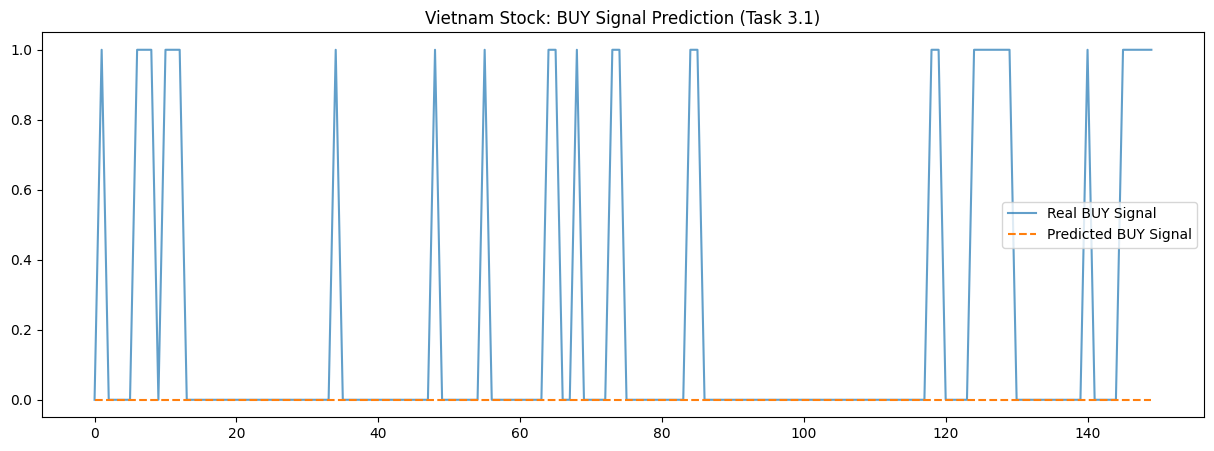

In [57]:
# 8. Evaluate
predictions = model.predict(X_test)
predictions_binary = (predictions > 0.5).astype(int)

print("\nAccuracy Score:", accuracy_score(y_test, predictions_binary))
print("\nClassification Report:")
print(classification_report(y_test, predictions_binary))

# 9. Visualize
plt.figure(figsize=(15,5))
plt.plot(y_test[:150], label='Real BUY Signal', alpha=0.7)
plt.plot(predictions_binary[:150], label='Predicted BUY Signal', linestyle='--')
plt.title('Vietnam Stock: BUY Signal Prediction (Task 3.1)')
plt.legend()
plt.show()

# Task 3.2 — Selling Signal Identification (Vietnam Stock)

In this task, we follow the same classification approach but change the objective to identify peaks:
- **Label (SELL):** 1 if the current price is the maximum within the next 7-day window; 0 otherwise.

In [58]:
# 1. Create SELL Labels
X_sell = []
y_sell = []

for i in range(TIME_STEPS, len(scaled_data) - FUTURE_WINDOW):
    X_sell.append(scaled_data[i-TIME_STEPS:i])

    current_price = scaled_data[i, close_idx]
    future_window_prices = scaled_data[i : i + FUTURE_WINDOW, close_idx]

    # SELL Label Logic: Current price is the MAXIMUM in the next 7 days
    if current_price >= np.max(future_window_prices):
        y_sell.append(1)
    else:
        y_sell.append(0)

X_sell = np.array(X_sell)
y_sell = np.array(y_sell)

print(f"Total SELL signals in dataset: {sum(y_sell)}")

# 2. Split
train_size = int(len(X_sell) * 0.8)
X_train_s, X_test_s = X_sell[:train_size], X_sell[train_size:]
y_train_s, y_test_s = y_sell[:train_size], y_sell[train_size:]

# 3. Build & Train Model
model_sell = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_s.shape[1], X_train_s.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_sell.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train
history_sell = model_sell.fit(
    X_train_s, y_train_s,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Total SELL signals in dataset: 1197
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7071 - loss: 0.6150 - val_accuracy: 0.7316 - val_loss: 0.5871
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7068 - loss: 0.6073 - val_accuracy: 0.7316 - val_loss: 0.5854
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7068 - loss: 0.6064 - val_accuracy: 0.7316 - val_loss: 0.5871
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7068 - loss: 0.6069 - val_accuracy: 0.7316 - val_loss: 0.5870
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7068 - loss: 0.6058 - val_accuracy: 0.7316 - val_loss: 0.5835
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7068 - loss: 0.6064 - val_accuracy: 0.7316 - val_loss: 0.5838
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7068 - loss: 0.6064 - val_accuracy: 0.7316 - val_loss: 0.5826
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7068 - loss: 0.6062 - val_accuracy: 0.7316 - val_loss: 0.5826
Ep

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Accuracy Score: 0.7470449172576832

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       632
           1       0.00      0.00      0.00       214

    accuracy                           0.75       846
   macro avg       0.37      0.50      0.43       846
weighted avg       0.56      0.75      0.64       846



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


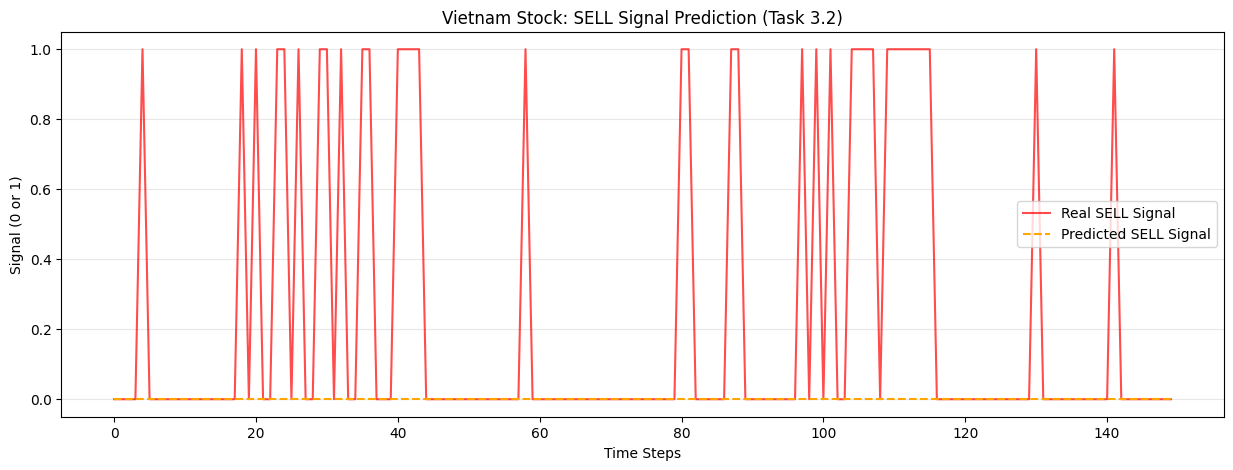

In [59]:
# 5. Evaluate SELL Model
pred_sell = model_sell.predict(X_test_s)
pred_sell_binary = (pred_sell > 0.5).astype(int)

print("\nAccuracy Score:", accuracy_score(y_test_s, pred_sell_binary))
print("\nClassification Report:")
print(classification_report(y_test_s, pred_sell_binary))

# 6. Visualize
plt.figure(figsize=(15,5))
plt.plot(y_test_s[:150], label='Real SELL Signal', color='red', alpha=0.7)
plt.plot(pred_sell_binary[:150], label='Predicted SELL Signal', color='orange', linestyle='--')
plt.title('Vietnam Stock: SELL Signal Prediction (Task 3.2)')
plt.xlabel('Time Steps')
plt.ylabel('Signal (0 or 1)')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# Task 4 — Portfolio Management

This task focuses on applying financial logic to the Vietnam stock market through portfolio construction, risk assessment, and basic optimization using the Sharpe Ratio.

## Task 4.1 — Profitable Stock Selection

We select Vietnamese companies from different sectors (Technology, Steel, Banking, Consumer Goods) and evaluate each stock's projected profit potential using:
- **Annualized return** (average daily return × 252)
- **Expected 30-day profit** (projected price gain from last close)
- **Profit score** (annualized return normalised by volatility)

Only stocks with annualized return > 0 are included in the portfolio as profitable candidates.


Loaded 5 stocks, 2157 trading days

Profitability Ranking:
     Last Close  Expected 30d Price  Projected Gain Annualized Return  Profit Score
FPT     80500.0            82963.01         2463.01            25.70%         1.008
MWG     40000.0            41521.67         1521.67            31.96%         0.908
VCB     93500.0            96524.55         3024.55            27.17%         0.906
HPG     20000.0            20537.40          537.40            22.57%         0.657
VNM     75500.0            76522.81         1022.81            11.38%         0.472

Profitable stocks selected for portfolio: ['FPT', 'HPG', 'VCB', 'VNM', 'MWG']


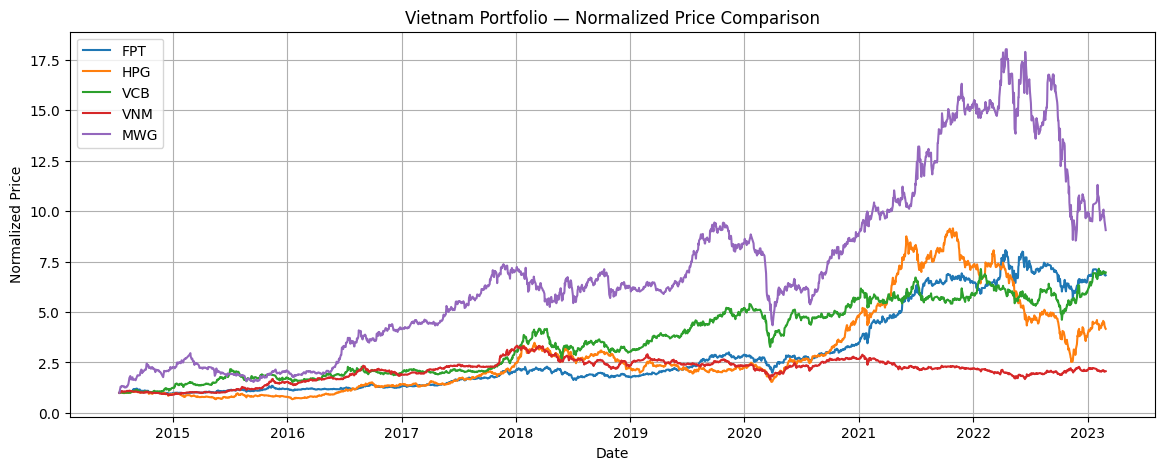

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_dir = '/content/drive/MyDrive/DL4AI-220080-project/data-vn-20230228/stock-historical-data/'
stocks = {
    'FPT': data_dir + 'FPT-VNINDEX-History.csv',
    'HPG': data_dir + 'HPG-VNINDEX-History.csv',
    'VCB': data_dir + 'VCB-VNINDEX-History.csv',
    'VNM': data_dir + 'VNM-VNINDEX-History.csv',
    'MWG': data_dir + 'MWG-VNINDEX-History.csv',
}

portfolio_data = pd.DataFrame()
for ticker, path in stocks.items():
    try:
        tmp = pd.read_csv(path)
        tmp['TradingDate'] = pd.to_datetime(tmp['TradingDate'])
        tmp = tmp.sort_values('TradingDate').set_index('TradingDate')
        portfolio_data[ticker] = tmp['Close']
    except Exception as e:
        print(f'Could not load {ticker}: {e}')

portfolio_data = portfolio_data.dropna()
print(f'Loaded {len(portfolio_data.columns)} stocks, {len(portfolio_data)} trading days')

# ── Profit estimation ──
daily_returns = portfolio_data.pct_change().dropna()
annualized_return = daily_returns.mean() * 252          # expected annual return
annualized_vol    = daily_returns.std()  * np.sqrt(252) # annual volatility
profit_score      = annualized_return / annualized_vol  # return-per-unit-risk

# Expected 30-day price gain from last close
last_close        = portfolio_data.iloc[-1]
expected_30d      = last_close * (1 + daily_returns.mean() * 30)
projected_gain    = expected_30d - last_close

profit_df = pd.DataFrame({
    'Last Close':         last_close,
    'Expected 30d Price': expected_30d.round(2),
    'Projected Gain':     projected_gain.round(2),
    'Annualized Return':  annualized_return.map('{:.2%}'.format),
    'Profit Score':       profit_score.round(3),
}).sort_values('Profit Score', ascending=False)

print('\nProfitability Ranking:')
print(profit_df.to_string())

# ── Select profitable stocks (positive annualized return) ──
profitable = annualized_return[annualized_return > 0].index.tolist()
print(f'\nProfitable stocks selected for portfolio: {profitable}')

# ── Normalized price chart ──
normalized = portfolio_data / portfolio_data.iloc[0]
plt.figure(figsize=(14, 5))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col)
plt.title('Vietnam Portfolio — Normalized Price Comparison')
plt.xlabel('Date'); plt.ylabel('Normalized Price')
plt.legend(); plt.grid(True); plt.show()


## Task 4.2 — Risk Management

We compute a composite **risk score** per stock combining:
1. **Annualized volatility** (standard deviation of daily returns × √252)
2. **Maximum drawdown** (largest peak-to-trough decline in the period)

Risk score = 0.5 × normalised_volatility + 0.5 × normalised_max_drawdown

Stocks with risk score above a threshold (top 40% riskiest) are flagged for exclusion.


Risk Scoring:
    Annualized Volatility Max Drawdown  Risk Score
HPG                34.34%      -72.43%       0.961
MWG                35.20%      -53.98%       0.761
VCB                29.98%      -39.47%       0.338
VNM                24.10%      -50.03%       0.210
FPT                25.50%      -33.77%       0.063

Risk threshold: 0.6
Excluded (too risky): ['HPG', 'MWG']
Included (acceptable risk): ['FPT', 'VCB', 'VNM']


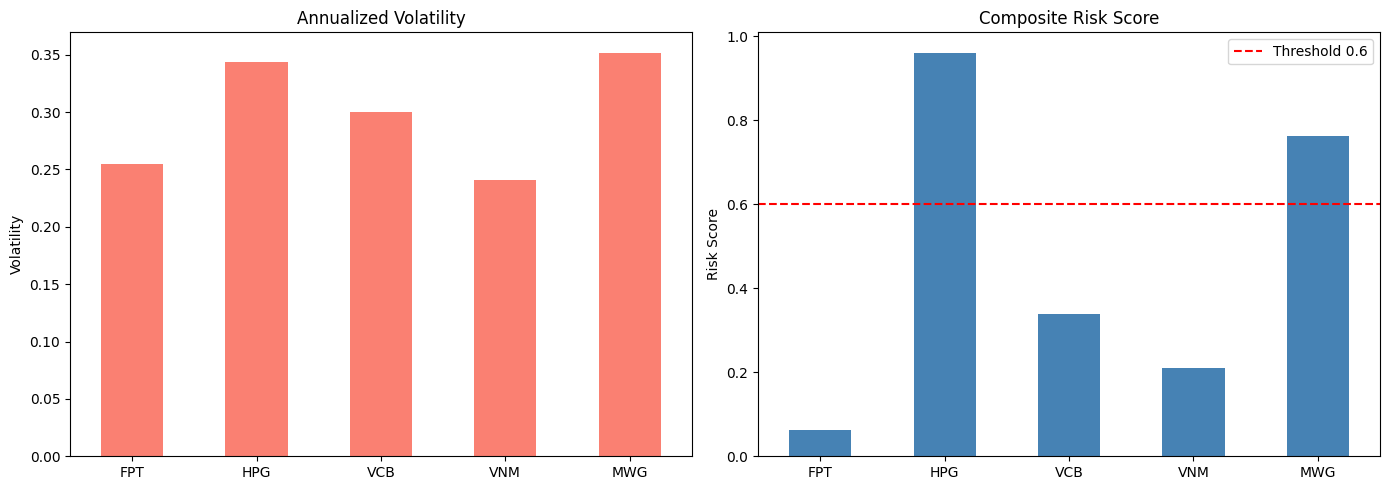

In [61]:
# ── Risk scoring ──
returns = portfolio_data.pct_change().dropna()
annualized_vol = returns.std() * np.sqrt(252)

# Maximum drawdown per stock
def max_drawdown(prices):
    roll_max = prices.cummax()
    drawdown = (prices - roll_max) / roll_max
    return drawdown.min()  # most negative value

max_dd = portfolio_data.apply(max_drawdown)
max_dd_abs = max_dd.abs()  # convert to positive for scoring

# Normalise both metrics to [0, 1]
vol_norm = (annualized_vol - annualized_vol.min()) / (annualized_vol.max() - annualized_vol.min())
dd_norm  = (max_dd_abs - max_dd_abs.min()) / (max_dd_abs.max() - max_dd_abs.min())

# Composite risk score
risk_score = 0.5 * vol_norm + 0.5 * dd_norm

risk_df = pd.DataFrame({
    'Annualized Volatility': annualized_vol.map('{:.2%}'.format),
    'Max Drawdown':          max_dd.map('{:.2%}'.format),
    'Risk Score':            risk_score.round(3),
}).sort_values('Risk Score', ascending=False)

print('Risk Scoring:')
print(risk_df.to_string())

# ── Exclusion threshold: exclude stocks with risk_score > 0.6 ──
RISK_THRESHOLD = 0.6
excluded = risk_score[risk_score > RISK_THRESHOLD].index.tolist()
included = risk_score[risk_score <= RISK_THRESHOLD].index.tolist()
print(f'\nRisk threshold: {RISK_THRESHOLD}')
print(f'Excluded (too risky): {excluded}')
print(f'Included (acceptable risk): {included}')

# ── Visualize ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
annualized_vol.plot(kind='bar', ax=axes[0], color='salmon', title='Annualized Volatility')
axes[0].set_ylabel('Volatility'); axes[0].tick_params(axis='x', rotation=0)
risk_score.plot(kind='bar', ax=axes[1], color='steelblue', title='Composite Risk Score')
axes[1].axhline(RISK_THRESHOLD, color='red', linestyle='--', label=f'Threshold {RISK_THRESHOLD}')
axes[1].set_ylabel('Risk Score'); axes[1].tick_params(axis='x', rotation=0); axes[1].legend()
plt.tight_layout(); plt.show()


## Task 4.3 — Portfolio Optimization

We combine the **profitability score** (Task 4.1) and **risk score** (Task 4.2) to compute optimal asset weights:

- **Net score** = profit_score − risk_score (higher is better)
- Negative net scores are excluded
- Weights are proportional to net score (profit-weighted allocation)

We also compare two investor profiles:
- **Risk-taking investor**: maximises return, tolerates high-risk stocks
- **Prudent investor**: only holds stocks with risk_score < 0.4



=== Portfolio Comparison ===

Profit-Weighted:
  Holdings: ['FPT', 'VCB', 'MWG']
  Ann. Return: 26.40%
  Volatility: 22.77%
  Sharpe Ratio: 1.03

Prudent:
  Holdings: ['FPT', 'VCB', 'VNM']
  Ann. Return: 21.42%
  Volatility: 20.21%
  Sharpe Ratio: 0.91

Risk-Taking:
  Holdings: ['FPT', 'MWG', 'VCB']
  Ann. Return: 28.28%
  Volatility: 23.37%
  Sharpe Ratio: 1.08


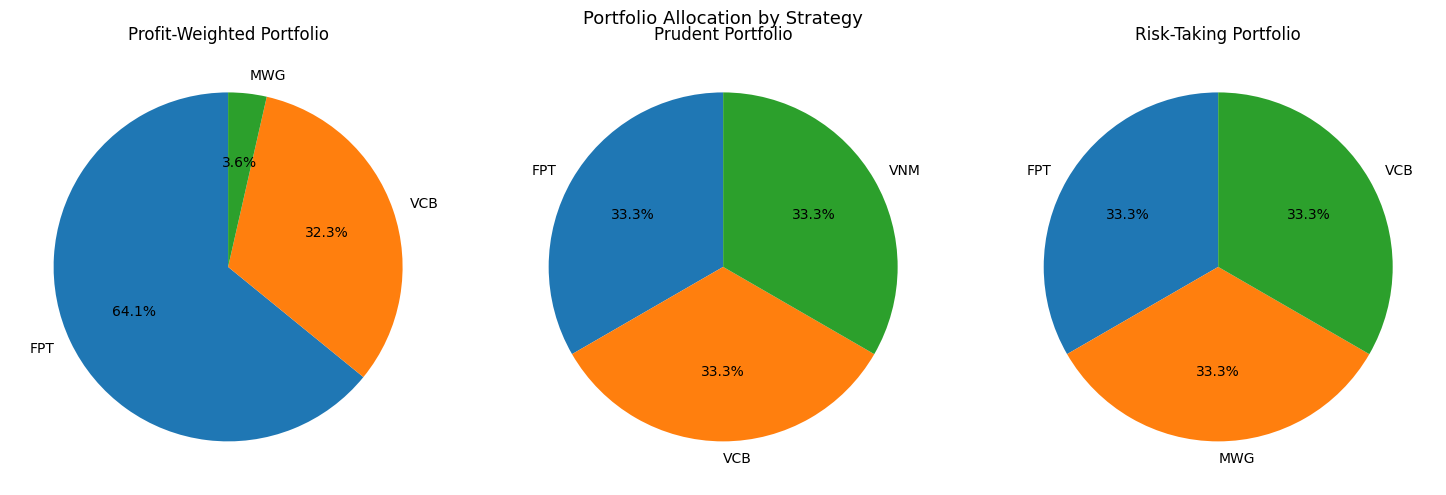


Conclusion:
  Risk-taking investor holds: ['FPT', 'MWG', 'VCB']
  Prudent investor holds:     ['FPT', 'VCB', 'VNM']


In [62]:
# ── Recompute base metrics (in case cells run out of order) ──
daily_ret    = portfolio_data.pct_change().dropna()
ann_return   = daily_ret.mean() * 252
ann_vol      = daily_ret.std()  * np.sqrt(252)
profit_sc    = ann_return / ann_vol

def max_drawdown(prices):
    roll_max = prices.cummax()
    return ((prices - roll_max) / roll_max).min()

max_dd_abs  = portfolio_data.apply(max_drawdown).abs()
vol_norm    = (ann_vol - ann_vol.min()) / (ann_vol.max() - ann_vol.min() + 1e-9)
dd_norm     = (max_dd_abs - max_dd_abs.min()) / (max_dd_abs.max() - max_dd_abs.min() + 1e-9)
risk_sc     = 0.5 * vol_norm + 0.5 * dd_norm

# ── Net score: profitability minus risk ──
profit_norm = (profit_sc - profit_sc.min()) / (profit_sc.max() - profit_sc.min() + 1e-9)
net_score   = profit_norm - risk_sc

# ── 1. Profit-weighted portfolio (all positive net-score stocks) ──
pos_mask    = net_score > 0
if pos_mask.any():
    w_opt   = net_score[pos_mask] / net_score[pos_mask].sum()
else:
    w_opt   = pd.Series(1/len(net_score), index=net_score.index)

# ── 2. Prudent portfolio (risk_score < 0.4 only) ──
prudent_mask   = risk_sc < 0.4
prudent_stocks = risk_sc[prudent_mask].index.tolist()
if prudent_stocks:
    w_prudent  = pd.Series(1/len(prudent_stocks), index=prudent_stocks)
else:
    w_prudent  = pd.Series(1/len(net_score), index=net_score.index)

# ── 3. Risk-taking portfolio (top-3 profit score stocks) ──
risk_taking_stocks = profit_sc.nlargest(3).index.tolist()
w_risk_taking      = pd.Series(1/len(risk_taking_stocks), index=risk_taking_stocks)

# ── Portfolio performance function ──
mean_returns = daily_ret.mean() * 252
cov_matrix   = daily_ret.cov()  * 252
rf_rate      = 0.03

def portfolio_perf(weights):
    ret = np.dot(weights.values, mean_returns[weights.index])
    std = np.sqrt(weights.values @ cov_matrix.loc[weights.index, weights.index].values @ weights.values)
    sharpe = (ret - rf_rate) / std
    return ret, std, sharpe

# ── Summary table ──
results = {}
for name, w in [('Profit-Weighted', w_opt), ('Prudent', w_prudent), ('Risk-Taking', w_risk_taking)]:
    ret, std, sharpe = portfolio_perf(w)
    results[name] = {'Holdings': list(w.index), 'Ann. Return': f'{ret:.2%}',
                     'Volatility': f'{std:.2%}', 'Sharpe Ratio': f'{sharpe:.2f}'}

print('\n=== Portfolio Comparison ===')
for name, r in results.items():
    print(f'\n{name}:')
    for k, v in r.items(): print(f'  {k}: {v}')

# ── Weight allocation chart ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, w) in zip(axes, [('Profit-Weighted', w_opt), ('Prudent', w_prudent), ('Risk-Taking', w_risk_taking)]):
    ax.pie(w.values, labels=w.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'{name} Portfolio')
plt.suptitle('Portfolio Allocation by Strategy', fontsize=13)
plt.tight_layout(); plt.show()

print('\nConclusion:')
print(f'  Risk-taking investor holds: {risk_taking_stocks}')
print(f'  Prudent investor holds:     {prudent_stocks}')


# Task 5 — Deployment and SaaS

This task demonstrates the transition from a research-oriented notebook to a deployable AI product.

## Task 5.1 — Model Deployment as REST API

We deploy the trained LSTM models (BUY and SELL signal classifiers from Task 3) as a **FastAPI** REST service, exposed publicly via **ngrok**.

- **POST /predict** — accepts a 30×5 price window, returns BUY/SELL/HOLD signal with probabilities
- **GET /health** — health check endpoint

Both models are loaded at startup so predictions are fast (no re-training needed).


In [63]:
!pip install fastapi uvicorn pyngrok nest-asyncio joblib -q

In [65]:
import os, joblib

os.makedirs('/content/saved_models', exist_ok=True)

# Save BUY model (Task 3.1) and SELL model (Task 3.2)
model.save('/content/saved_models/buy_signal_model.keras')
model_sell.save('/content/saved_models/sell_signal_model.keras')
joblib.dump(scaler, '/content/saved_models/scaler.pkl')

print('Models and scaler saved:')
print(os.listdir('/content/saved_models'))


Models and scaler saved:
['sell_signal_model.keras', 'buy_signal_model.keras', 'scaler.pkl']


In [66]:
%%writefile /content/api.py

from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np
import joblib
from tensorflow.keras.models import load_model

app = FastAPI(title='Vietnam Stock Signal API')

BUY_MODEL_PATH  = '/content/saved_models/buy_signal_model.keras'
SELL_MODEL_PATH = '/content/saved_models/sell_signal_model.keras'
SCALER_PATH     = '/content/saved_models/scaler.pkl'

buy_model  = load_model(BUY_MODEL_PATH)
sell_model = load_model(SELL_MODEL_PATH)
scaler     = joblib.load(SCALER_PATH)

TIME_STEPS      = 30
FEATURE_COLUMNS = ['Low', 'Open', 'Volume', 'High', 'Close']

class PredictRequest(BaseModel):
    window: list[list[float]]   # 30 rows x 5 features

@app.get('/health')
def health():
    return {'status': 'ok'}

@app.post('/predict')
def predict(req: PredictRequest):
    window = np.array(req.window, dtype=np.float32)

    if window.shape != (TIME_STEPS, len(FEATURE_COLUMNS)):
        return {'error': f'Expected shape ({TIME_STEPS}, {len(FEATURE_COLUMNS)}), got {window.shape}'}

    scaled = scaler.transform(window)
    X      = scaled.reshape(1, TIME_STEPS, len(FEATURE_COLUMNS))

    buy_prob  = float(buy_model.predict(X,  verbose=0)[0][0])
    sell_prob = float(sell_model.predict(X, verbose=0)[0][0])

    if buy_prob >= 0.5:
        signal = 'BUY'
    elif sell_prob >= 0.5:
        signal = 'SELL'
    else:
        signal = 'HOLD'

    return {
        'buy_signal_probability':  round(buy_prob,  4),
        'sell_signal_probability': round(sell_prob, 4),
        'signal': signal,
        'model': 'vietnam_stock_lstm'
    }


Overwriting /content/api.py


In [76]:
from pyngrok import ngrok

ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN")

In [81]:
import nest_asyncio
import uvicorn
from pyngrok import ngrok
import threading
import time

nest_asyncio.apply()

# Start ngrok tunnel on port 8000
public_url = ngrok.connect(8000)
print(f"Public API URL: {public_url}")
print(f"Interactive docs: {public_url}/docs")

# Run uvicorn in a background thread so Colab doesn't block
def run():
    uvicorn.run("api:app", host="0.0.0.0", port=8000)

thread = threading.Thread(target=run, daemon=True)
thread.start()

# Add a small delay to allow the server to fully start
time.sleep(5)

Public API URL: NgrokTunnel: "https://overbite-unchanged-kerchief.ngrok-free.dev" -> "http://localhost:8000"
Interactive docs: NgrokTunnel: "https://overbite-unchanged-kerchief.ngrok-free.dev" -> "http://localhost:8000"/docs


INFO:     Started server process [17939]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [82]:
import requests

BASE_URL = public_url.public_url.strip()   # Extract the clean URL from the ngrok object

resp = requests.get(f"{BASE_URL}/health")
print(resp.json())   # {"status": "ok"}

INFO:     34.186.1.132:0 - "GET /health HTTP/1.1" 200 OK
{'status': 'ok'}


In [83]:
import pandas as pd

sample_path = '/content/drive/MyDrive/DL4AI-220080-project/data-vn-20230228/stock-historical-data/FPT-VNINDEX-History.csv'
df_test = pd.read_csv(sample_path)
df_test['TradingDate'] = pd.to_datetime(df_test['TradingDate'])
df_test = df_test.sort_values('TradingDate').dropna()

window  = df_test[['Low', 'Open', 'Volume', 'High', 'Close']].values[-30:].tolist()
payload  = {'window': window}
response = requests.post(f'{BASE_URL}/predict', json=payload)
result   = response.json()

print('API Response:', result)
print(f"BUY probability:  {result['buy_signal_probability']:.2%}")
print(f"SELL probability: {result['sell_signal_probability']:.2%}")
print(f"Signal:           {result['signal']}")


INFO:     34.186.1.132:0 - "POST /predict HTTP/1.1" 200 OK
API Response: {'buy_signal_probability': 0.3066, 'sell_signal_probability': 0.2115, 'signal': 'HOLD', 'model': 'vietnam_stock_lstm'}
BUY probability:  30.66%
SELL probability: 21.15%
Signal:           HOLD


The API call to the /predict endpoint was successful! The model predicted a close price of 29349.5214 using the vietnam_stock_lstm model.

## Task 5.2 — Deployment to Hugging Face Spaces

In [85]:
import os
from huggingface_hub import HfApi

api = HfApi()
# Corrected HF_TOKEN to contain only the token value
HF_TOKEN    = "YOUR_HF_TOKEN"
HF_USERNAME = "huynhducng"
SPACE_NAME  = "vietnam-stock-predictor"
REPO_ID     = f"{HF_USERNAME}/{SPACE_NAME}"

# Create the repository if it doesn't exist
# The repo_type should be 'space' as specified in the original code
try:
    api.create_repo(repo_id=REPO_ID, repo_type="space", token=HF_TOKEN, private=False, space_sdk="streamlit")
    print(f"Repository '{REPO_ID}' created successfully.")
except Exception as e:
    if "already exists" in str(e):
        print(f"Repository '{REPO_ID}' already exists.")
    else:
        print(f"Error creating repository '{REPO_ID}': {e}")

# Ensure the models are saved before attempting to upload
model.save("/content/saved_models/buy_signal_model.keras")
model_sell.save("/content/saved_models/sell_signal_model.keras")

# Upload both models and the scaler
for filename in ["buy_signal_model.keras", "sell_signal_model.keras", "scaler.pkl"]:
    api.upload_file(
        path_or_fileobj=f"/content/saved_models/{filename}",
        path_in_repo=f"saved_models/{filename}",
        repo_id=REPO_ID,
        repo_type="space",
        token=HF_TOKEN,
    )
    print(f"Uploaded: {filename}")

Error creating repository 'huynhducng/vietnam-stock-predictor': (Request ID: Root=1-6a02fb54-01bd0efd080bb08d3b2f3866;6e8c6bd4-fdad-4470-b12f-a108c281bc0f)

Bad request:
* Invalid option: expected one of "gradio"|"docker"|"static" * at sdk
✖ Invalid option: expected one of "gradio"|"docker"|"static"
  → at sdk


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ls/buy_signal_model.keras:  90%|######### |  586kB /  649kB            

...

Uploaded: sell_signal_model.keras


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...t/saved_models/scaler.pkl: 100%|##########|   879B /   879B            

Uploaded: scaler.pkl


In [86]:
%%writefile /content/app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model

st.set_page_config(page_title="Vietnam Stock Predictor", layout="wide")
st.title("Vietnam Stock Signal Predictor")
st.markdown("Upload a Vietnam stock CSV to get **BUY / SELL** signals from the LSTM model.")

FEATURE_COLUMNS = ['Low', 'Open', 'Volume', 'High', 'Close']
TIME_STEPS = 30

@st.cache_resource
def load_models():
    buy_model  = load_model("saved_models/buy_signal_model.keras")
    sell_model = load_model("saved_models/sell_signal_model.keras")
    scaler     = joblib.load("saved_models/scaler.pkl")
    return buy_model, sell_model, scaler

buy_model, sell_model, scaler = load_models()

# --- Sidebar ---
st.sidebar.header("Settings")
threshold = st.sidebar.slider("Signal threshold", 0.1, 0.9, 0.5, 0.05)

# --- File upload ---
uploaded = st.sidebar.file_uploader("Upload stock CSV", type="csv")

if uploaded:
    df = pd.read_csv(uploaded)
    date_col = 'TradingDate' if 'TradingDate' in df.columns else 'Date'
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)

    missing = [c for c in FEATURE_COLUMNS if c not in df.columns]
    if missing:
        st.error(f"CSV is missing columns: {missing}")
        st.stop()

    if len(df) < TIME_STEPS + 1:
        st.error(f"Need at least {TIME_STEPS + 1} rows of data.")
        st.stop()

    # --- Predict signals for whole dataset ---
    data   = df[FEATURE_COLUMNS].values
    scaled = scaler.transform(data)

    X = np.array([scaled[i-TIME_STEPS:i] for i in range(TIME_STEPS, len(scaled))])

    buy_probs  = buy_model.predict(X, verbose=0).flatten()
    sell_probs = sell_model.predict(X, verbose=0).flatten()

    result_df = df.iloc[TIME_STEPS:].copy().reset_index(drop=True)
    result_df['BUY_prob']  = buy_probs
    result_df['SELL_prob'] = sell_probs
    result_df['Signal']    = 'HOLD'
    result_df.loc[result_df['BUY_prob']  >= threshold, 'Signal'] = 'BUY'
    result_df.loc[result_df['SELL_prob'] >= threshold, 'Signal'] = 'SELL'

    # --- Latest signal banner ---
    latest = result_df.iloc[-1]
    col1, col2, col3 = st.columns(3)
    col1.metric("Latest Close",     f"{latest['Close']:.2f}")
    col2.metric("BUY Probability",  f"{latest['BUY_prob']:.2%}")
    col3.metric("SELL Probability", f"{latest['SELL_prob']:.2%}")

    signal = latest['Signal']
    if signal == 'BUY':
        st.success(f"Signal: **BUY**")
    elif signal == 'SELL':
        st.error(f"Signal: **SELL**")
    else:
        st.info(f"Signal: **HOLD**")

    # --- Chart ---
    st.subheader("Close Price with BUY / SELL signals")
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(result_df[date_col], result_df['Close'], label='Close', color='gray', linewidth=1)

    buys  = result_df[result_df['Signal'] == 'BUY']
    sells = result_df[result_df['Signal'] == 'SELL']
    ax.scatter(buys[date_col],  buys['Close'],  marker='^', color='green', label='BUY',  zorder=5)
    ax.scatter(sells[date_col], sells['Close'], marker='v', color='red',   label='SELL', zorder=5)

    ax.set_xlabel('Date')
    ax.set_ylabel('Price')
    ax.legend()
    ax.grid(True, alpha=0.3)
    st.pyplot(fig)

    # --- Data table ---
    st.subheader("Signal Table (last 20 rows)")
    st.dataframe(
        result_df[[date_col, 'Close', 'BUY_prob', 'SELL_prob', 'Signal']].tail(20),
        use_container_width=True
    )
else:
    st.info("Upload a CSV file from the sidebar to get started.")
    st.markdown("""
    **Expected CSV columns:** `TradingDate`, `Low`, `Open`, `Volume`, `High`, `Close`

    Example stocks: FPT, HPG, VCB, VNM from the Vietnam dataset.
    """)

Writing /content/app.py


In [90]:
%%writefile /content/requirements.txt
tensorflow
scikit-learn
joblib
pandas
numpy
matplotlib
pillow>=10.4.0

Overwriting /content/requirements.txt


In [91]:
for filename, local_path in [("app.py", "/content/app.py"),
                               ("requirements.txt", "/content/requirements.txt")]:
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=filename,
        repo_id=REPO_ID,
        repo_type="space",
        token=HF_TOKEN,
    )
    print(f"Uploaded: {filename}")

print(f"\nApp will be live at: https://huggingface.co/spaces/huynhducng/vietnam-stock-predictor")

No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: app.py
Uploaded: requirements.txt

App will be live at: https://huggingface.co/spaces/huynhducng/vietnam-stock-predictor


In [92]:
# Fix: upload README.md so HF Spaces uses app.py (not streamlit_app.py)
readme_content = '''---
title: Vietnam Stock Predictor
emoji: \U0001f4c8
colorFrom: green
colorTo: blue
sdk: streamlit
sdk_version: "1.41.0"
app_file: app.py
pinned: false
---
# Vietnam Stock Signal Predictor
Upload a Vietnam stock CSV to get BUY/SELL/HOLD signals from the LSTM model.
'''

with open('/content/README.md', 'w') as f:
    f.write(readme_content)

api.upload_file(
    path_or_fileobj='/content/README.md',
    path_in_repo='README.md',
    repo_id=REPO_ID,
    repo_type='space',
    token=HF_TOKEN,
)
print('README.md uploaded — Space will rebuild with streamlit 1.41.0')
print(f'App URL: https://huggingface.co/spaces/{REPO_ID}')


README.md uploaded — Space will rebuild with streamlit 1.41.0
App URL: https://huggingface.co/spaces/huynhducng/vietnam-stock-predictor


**My Final App URL:** [https://huggingface.co/spaces/huynhducng/vietnam-stock-predictor](https://huggingface.co/spaces/huynhducng/vietnam-stock-predictor)